**Challenge 1**
Text mining

1.  `Setup URL`

In [1]:
url = 'https://en.wikipedia.org/wiki/Data_science'

headers = {
    'User-Agent': 'BelajarDataScience/1.0 ()' 
}

2. `Ambil Data`

In [2]:
import requests

try:
    response = requests.get(url, headers=headers).content.decode('utf-8')
    print(response[:1000])
except Exception as e:
    print(e)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Data science - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feat

3. `Rubah data`

In [3]:
from bs4 import BeautifulSoup

#  mengurai konten HTMl
soup = BeautifulSoup(response, "lxml")

# mengambil hanya artikel utama
# wikipedia menggunakan class 'mw-parser-output' pada konten artikel utamanya
konten = soup.find('div', class_='mw-parser-output') 

def membersihkan_konten_wiki(node_konten):
    """Menghapus elemen non-artikel umum"""
    # Strip jump links, navboxes, reference lists/superscripts, edit sections, TOC, sidebars, etc.
    selectors = [
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
    for selector in selectors:
        for el in node_konten.select(selector):
            el.decompose()

if konten:
    # membersihkan konten agar mendapat tulisan saja
    membersihkan_konten_wiki(konten)
    teks = konten.get_text(separator=' ', strip=True)
    print(teks[:1000])
else:
    print("Tidak dapat menemukan konten utama")
    teks = konten.get_text(separator=' ', strip=True)
    print(teks[:1000])

Field of study to extract knowledge from data The existence of Comet NEOWISE (here depicted as a series of red dots) was discovered by analyzing astronomical survey data acquired by a space telescope , the Wide-field Infrared Survey Explorer . Data science is an interdisciplinary academic field that uses statistics , scientific computing , scientific methods , processing, scientific visualization , algorithms , and systems to extract or extrapolate knowledge from potentially noisy, structured , or unstructured data . Data science also integrates domain knowledge from the underlying application domain (e.g., natural sciences, information technology, and medicine). Data science is multifaceted and can be described as a science, a research paradigm, a research method, a discipline, a workflow, and a profession. Data science is "a concept to unify statistics , data analysis , informatics , and their related methods " to "understand and analyze actual phenomena " with data . It uses techniq

4. `Mengambil Insight`

In [4]:
import nlp_rake
extractor = nlp_rake.Rake(max_words=2, min_freq=3, min_chars=5)
res = extractor.apply(teks)
res

[('data scientist', 4.0),
 ('sexiest job', 4.0),
 ('21st century', 4.0),
 ('statistical learning', 4.0),
 ('big data', 4.0),
 ('data science', 3.9047619047619047),
 ('computer science', 3.9047619047619047),
 ('^ davenport', 3.8),
 ('information science', 3.738095238095238),
 ('data analysis', 3.7272727272727275),
 ('cloud computing', 3.666666666666667),
 ('science', 1.9047619047619047),
 ('analysis', 1.7272727272727273),
 ('computing', 1.6666666666666667),
 ('sciences', 1.4),
 ('statistics', 1.3),
 ('processing', 1.25),
 ('education', 1.25),
 ('field', 1.2),
 ('thomas', 1.2),
 ('study', 1.0),
 ('techniques', 1.0),
 ('report', 1.0),
 ('process', 1.0),
 ('david', 1.0),
 ('communications', 1.0),
 ('chikio', 1.0),
 ('bibcode', 1.0)]

4. `Visualisasi Hasil`

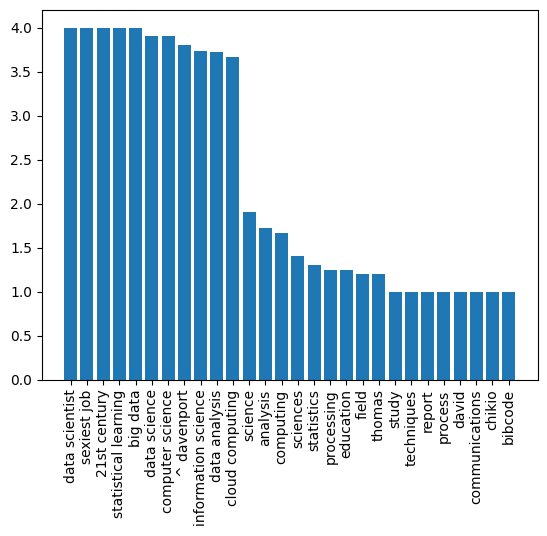

In [5]:
import matplotlib.pyplot as plt

def plot(pair_list):
    k, v =zip(*pair_list)
    plt.bar(range(len(k)),v)
    plt.xticks(range(len(k)),k,rotation='vertical')
    plt.show()

plot(res)

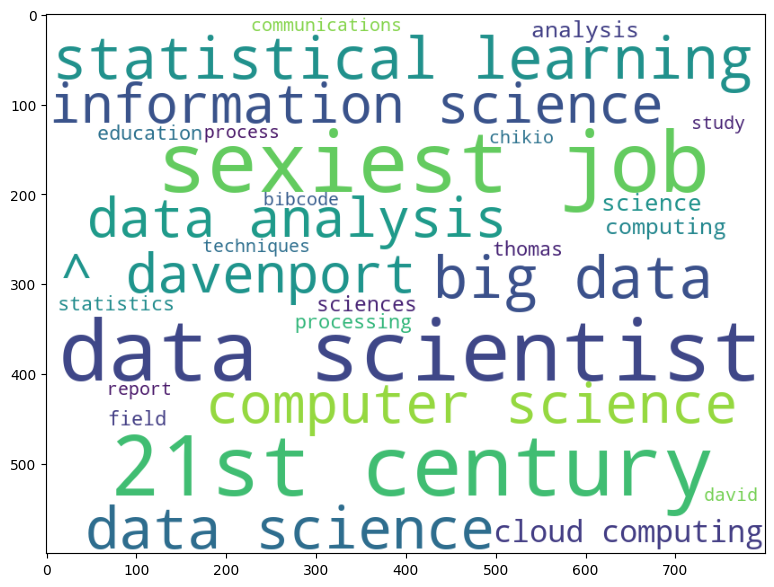

In [6]:
from wordcloud import WordCloud

wc = WordCloud(background_color='white', width=800, height=600)
plt.figure(figsize=(15,7))
plt.imshow(wc.generate_from_frequencies({k:v for k,v in res}))

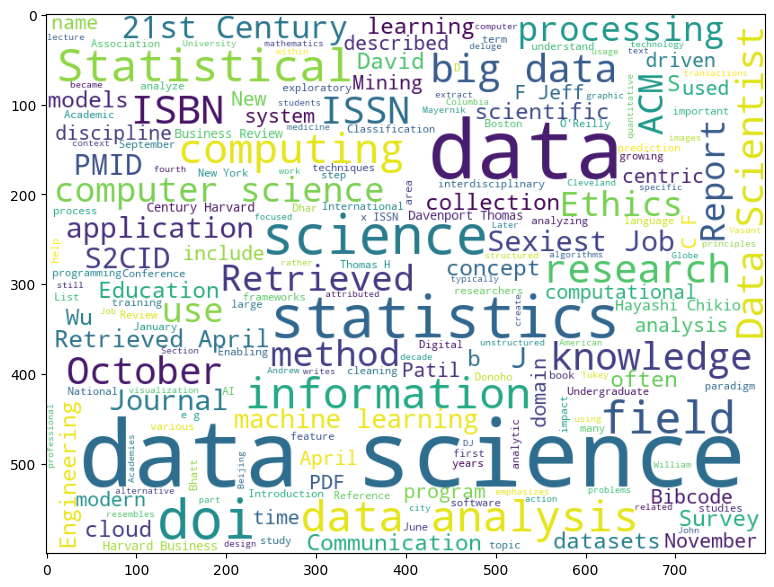

In [7]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(teks))

In [8]:
# wc.generate(teks).to_file('images/ds_wordcloud.png')

**BIG DATA**

1. menghubungkan ke data

In [9]:
link = "https://en.wikipedia.org/wiki/Big_data"

headers = {
    'User-Agent' : 'BelajarDataScience/1.0 ())'
}

try:
    respon = requests.get(link, headers=headers)
    if respon.status_code == 200:
        print("Berhasil terhubung ke server\n")
        # print(respon[:1000])
except Exception as e:
    print(e)


Berhasil terhubung ke server



2. mengambil data

In [10]:
dataBD = respon.content.decode('utf-8')
print(dataBD[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Big data - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-

In [11]:
soupBD = BeautifulSoup(dataBD, "lxml")

kontenBD = soupBD.find('div', class_='mw-parser-output')

if kontenBD:
    membersihkan_konten_wiki(kontenBD)
    teksBD = kontenBD.get_text(separator= ' ', strip=True)
    print(teksBD[:1000])
else:
    print("Tidak dapat menemukan teks")
    teksBD = kontenBD.get_text(separator= ' ', strip=True)
    print(teksBD[:1000])


Extremely large or complex datasets A diagram of the generation and common application of big data Big data primarily refers to data sets that are too large or complex to be dealt with by traditional data-processing software . Data with many entries (rows) offers greater statistical power , while data with higher complexity (more attributes or columns) may lead to a higher false discovery rate . Big data analysis challenges include capturing data , data storage , data analysis , search, sharing , transfer , visualization , querying , updating, information privacy , and data sources. Big data was originally associated with three key concepts: volume , variety , and velocity . The analysis of big data that have only volume, velocity, and variety can pose challenges in sampling . A fourth concept, veracity, which refers to the level of reliability of data, was thus added . Without sufficient investment in expertise to ensure big data veracity, the volume and variety of data can produce co

3. mengambil insight

In [12]:
ekstraksiBD = nlp_rake.Rake(max_words=4, min_freq=7, min_chars=5)
resBD = ekstraksiBD.apply(teksBD)
resBD

[('big data', 5.003999623564841),
 ('machine learning', 4.7),
 ('data collected', 4.435817805383023),
 ('international journal', 3.9502262443438916),
 ('retrieved 29 december 2016', 3.4545028142589116),
 ('retrieved 9 august 2013', 3.4301125703564725),
 ('retrieved 8 october 2017', 3.422307692307692),
 ('analysis', 2.2285714285714286),
 ('science', 2.225),
 ('information', 2.0384615384615383),
 ('challenges', 1.9565217391304348),
 ('marketing', 1.7894736842105263),
 ('development', 1.7391304347826086),
 ('technologies', 1.7333333333333334),
 ('world', 1.7272727272727273),
 ('society', 1.6923076923076923),
 ('volume', 1.6875),
 ('needed', 1.5625),
 ('journal', 1.5384615384615385),
 ('internet', 1.4705882352941178),
 ('order', 1.2222222222222223),
 ('nature', 1.2),
 ('consumers', 1.125),
 ('archived', 1.0389610389610389),
 ('variety', 1.0),
 ('update', 1.0),
 ('original', 1.0),
 ('bibcode', 1.0),
 ('1016/j', 1.0),
 ('https', 1.0)]

4. visualisasi

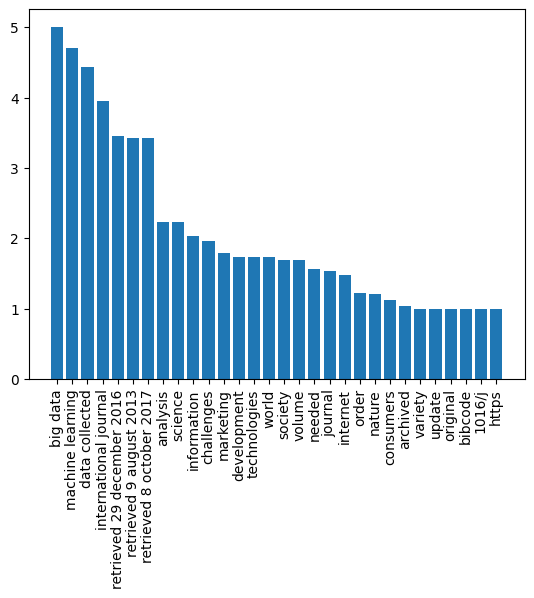

In [13]:
plot(resBD)

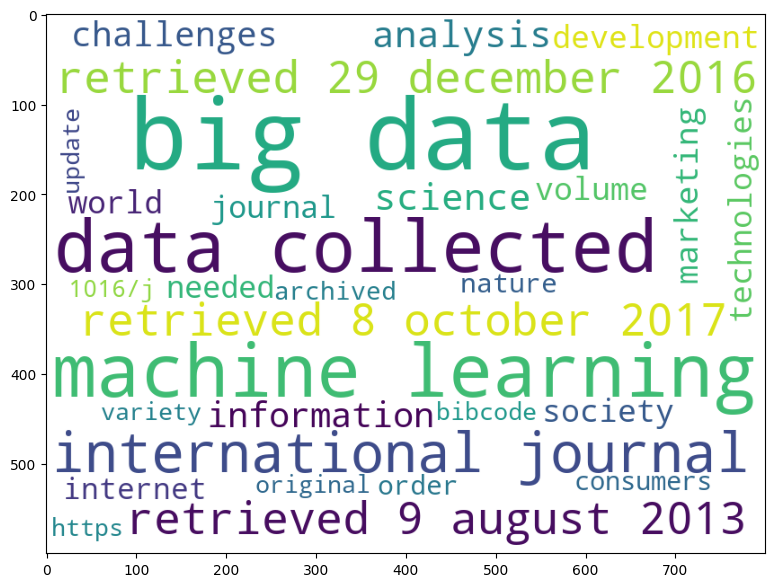

In [14]:
def membuat_wordcloud(target):
    wc = WordCloud(background_color='white', width=800, height=600)
    plt.figure(figsize=(15,7))
    plt.imshow(wc.generate_from_frequencies({k:v for k,v in target}))

membuat_wordcloud(resBD)

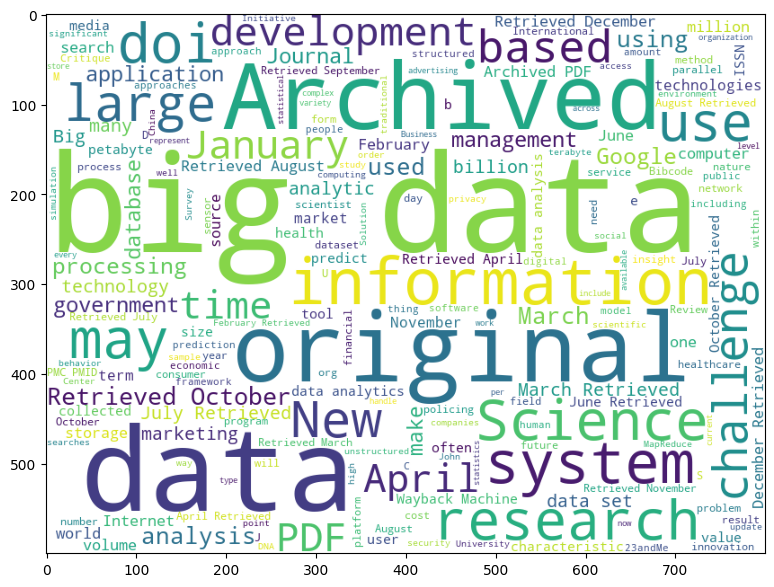

In [15]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(teksBD))

In [16]:
# wc.generate(teksBD).to_file('images/bd_wordcloud.png')

**Machine learning**

1. Set Up dan Koneksi ke data

In [17]:
from wordcloud_makerku import AmbilData
data = AmbilData("https://en.wikipedia.org/wiki/Machine_learning",  "BelajarDataScience")

data.konek_data()

Berhasil terhubung ke server data


2. Ambil data

In [18]:
data.ambil_data()

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled wp25eastereggs-enable-clientpref-1 vector-toc-available skin-theme-clientpref-thumb-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Machine learning - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-

3. Urai data

In [19]:
data.urai_data()

Study of algorithms that improve automatically through experience Machine learning ( ML ) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions . Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks , a class of statistical algorithms, to surpass many previous machine learning approaches in performance. Statistics and mathematical optimisation (mathematical programming) methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning . From a theoretical viewpoint, probably approximately correct learning provides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning alg

4. mengambil insight

In [20]:
insight = data.ambil_insight()
print(insight)

[('data mining', 4.0), ('dimensionality reduction', 4.0), ('data set', 4.0), ('polynomial time', 4.0), ('anomaly detection', 4.0), ('decision tree', 4.0), ('language corpora', 4.0), ('prentice hall', 4.0), ('mit press', 4.0), ('wayback machine', 3.9789473684210526), ('artificial neuron', 3.9722222222222223), ('deep learning', 3.9577464788732395), ('feature learning', 3.9577464788732395), ('reinforcement learning', 3.9577464788732395), ('statistical learning', 3.9577464788732395), ('machine learning', 3.936693847294292), ('artificial intelligence', 3.898148148148148), ('bayesian networks', 3.875), ('supervised learning', 3.8668373879641487), ('neural networks', 3.857142857142857), ('pattern recognition', 3.857142857142857), ('speech recognition', 3.833333333333333), ('statistical physics', 3.8), ('^ bozinovski', 3.7907407407407407), ('international conference', 3.7777777777777777), ('unsupervised learning', 3.7759282970550574), ('artificial neurons', 3.772222222222222), ('citation neede

5. visualisasi

In [21]:
from wordcloud_makerku import Visualisasi
ml = Visualisasi(insight, 10)

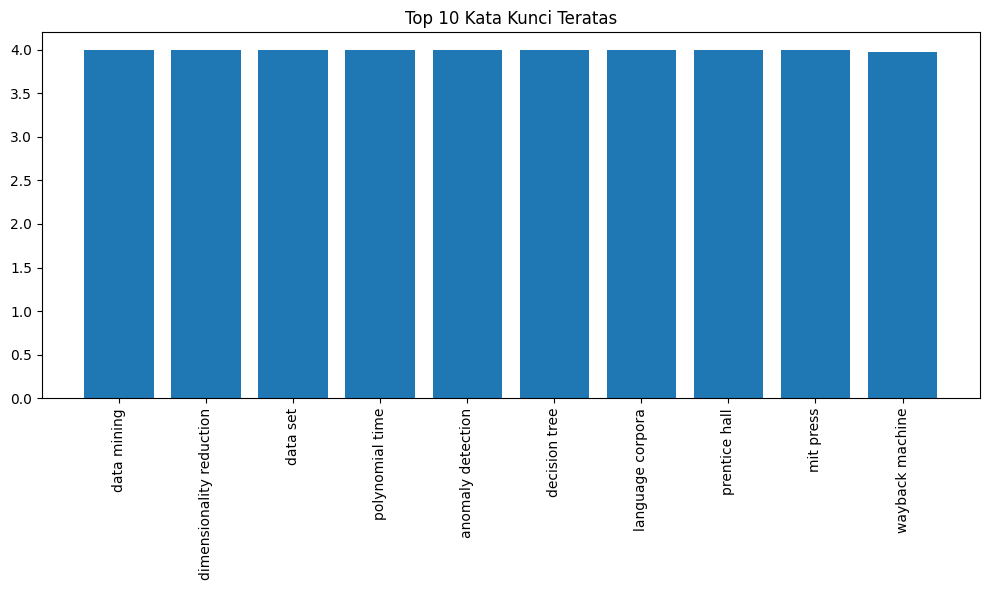

In [22]:
ml.bar_chart()

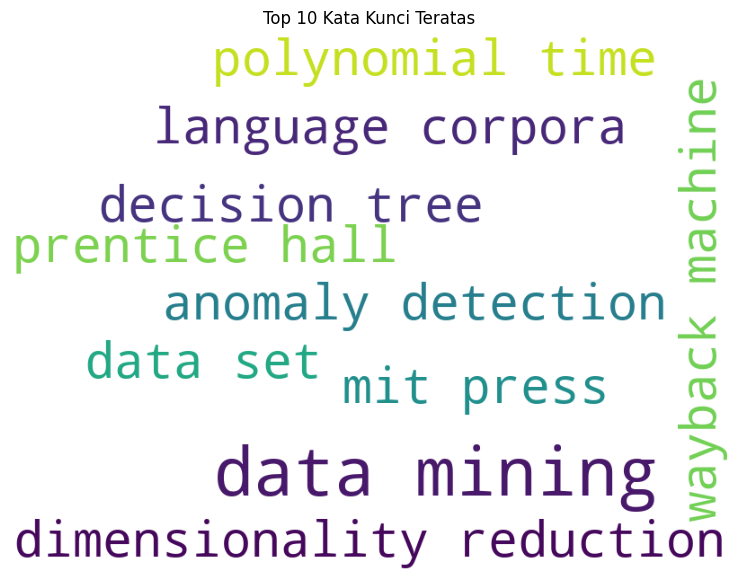

In [23]:
ml.wordcloud_maker()

In [24]:
dboard = Visualisasi(insight)

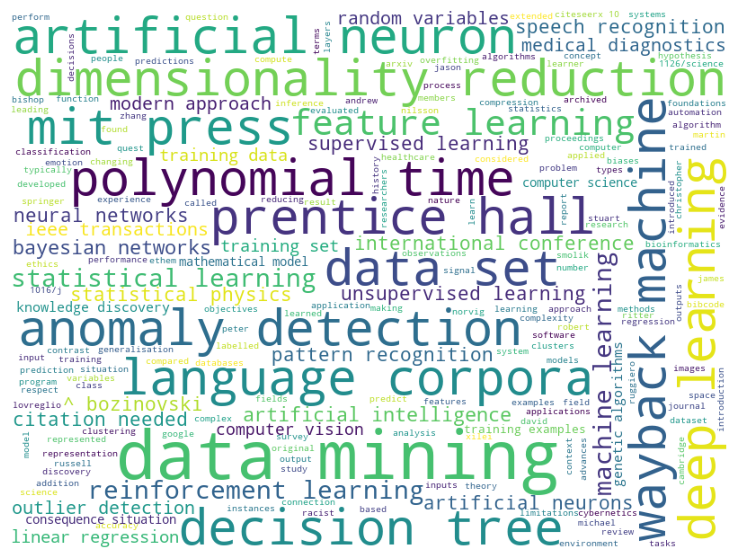

In [25]:
dboard.wordcloud_maker().to_file('images/ml_wordcloud.png')